In [2]:
## Taylor series code
## sin(x) = x - x^3 / 3! + x^5 / 5! - x^7 / 7! + ...
## alternating signs, odd powers match coeffeicent of factorial.

import math
import numpy as np

def taysin(n, x):
    return (-1)**n * ((x**(2*n+1)) / (math.factorial(2*n+1)))

def main(n, x):
    total = 0
    for i in range(n):
        total += taysin(i, x)
    return total 

In [3]:
# Compute the approximate values of sin⁡(x) for x=0 to 10, steps of .1 using the truncated series with 1, 2, 3, and 4 terms.

# 1) Calculate exact value
j = 0
exact_value = []
while (j <= 10):
    exact_value.append(np.sin(j))
    j += 0.1

    
print(exact_value)

[0.0, 0.09983341664682815, 0.19866933079506122, 0.2955202066613396, 0.3894183423086505, 0.479425538604203, 0.5646424733950354, 0.644217687237691, 0.7173560908995227, 0.7833269096274833, 0.8414709848078964, 0.8912073600614353, 0.9320390859672263, 0.963558185417193, 0.9854497299884603, 0.9974949866040544, 0.9995736030415051, 0.9916648104524686, 0.973847630878195, 0.9463000876874142, 0.9092974268256815, 0.8632093666488735, 0.8084964038195899, 0.7457052121767197, 0.6754631805511503, 0.5984721441039558, 0.5155013718214634, 0.42737988023382895, 0.33498815015590383, 0.23924932921398112, 0.1411200080598659, 0.04158066243328916, -0.05837414342758142, -0.15774569414324996, -0.25554110202683294, -0.3507832276896215, -0.44252044329485407, -0.5298361409084948, -0.6118578909427207, -0.6877661591839753, -0.7568024953079294, -0.8182771110644114, -0.8715757724135886, -0.9161659367494552, -0.951602073889516, -0.977530117665097, -0.9936910036334644, -0.9999232575641008, -0.9961646088358408, -0.9824526126

In [4]:
# 2) Compute the approximate values of sin⁡(x) for x=0 to 10, steps of .1 using the truncated series with 1, 2, 3, and 4 terms
approx_values_dict = {}

for step in range(101):      # 0 to 100 inclusive
    x = step * 0.1
    approx_values_dict[x] = []

    for n in range(1, 5):    # 1, 2, 3, 4 terms
        approx_values_dict[x].append(main(n, x))
        
print(len(approx_values_dict))
print(approx_values_dict[0.0])
print(approx_values_dict[1.0])
print(approx_values_dict)
        

101
[0.0, 0.0, 0.0, 0.0]
[1.0, 0.8333333333333334, 0.8416666666666667, 0.841468253968254]
{0.0: [0.0, 0.0, 0.0, 0.0], 0.1: [0.1, 0.09983333333333334, 0.09983341666666667, 0.09983341664682541], 0.2: [0.2, 0.19866666666666669, 0.19866933333333336, 0.19866933079365082], 0.30000000000000004: [0.30000000000000004, 0.29550000000000004, 0.29552025000000004, 0.2955202066071429], 0.4: [0.4, 0.38933333333333336, 0.3894186666666667, 0.3894183415873016], 0.5: [0.5, 0.4791666666666667, 0.47942708333333334, 0.479425533234127], 0.6000000000000001: [0.6000000000000001, 0.5640000000000001, 0.564648, 0.5646424457142858], 0.7000000000000001: [0.7000000000000001, 0.6428333333333334, 0.6442339166666667, 0.6442175765277779], 0.8: [0.8, 0.7146666666666667, 0.7173973333333333, 0.7173557231746032], 0.9: [0.9, 0.7785, 0.78342075, 0.7833258498214286], 1.0: [1.0, 0.8333333333333334, 0.8416666666666667, 0.841468253968254], 1.1: [1.1, 0.8781666666666667, 0.8915875833333333, 0.8912009331150793], 1.2000000000000002: 

In [5]:
import matplotlib.pyplot as plt

x_values = [step * 0.1 for step in range(101)]

# Create error storage
errors = {1: [], 2: [], 3: [], 4: []}

for idx, x in enumerate(x_values):
    exact = exact_value[idx]

    for n in range(1, 5):
        approx = approx_values_dict[x][n-1]
        error = abs(exact - approx)
        errors[n].append(error)


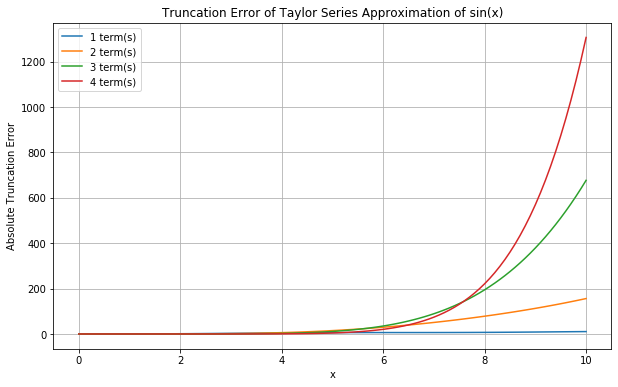

In [6]:
plt.figure(figsize=(10,6))

for n in range(1, 5):
    plt.plot(x_values, errors[n], label=f"{n} term(s)")

plt.xlabel("x")
plt.ylabel("Absolute Truncation Error")
plt.title("Truncation Error of Taylor Series Approximation of sin(x)")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
# Discuss -> 
# Since sin(x) is centered around 0, the error increases as x moves from 0. The truncation error increases when used
# with a higher x value because of how the taylor series begins. When paired with higher x values, the x^(2n + 1) term gets huge
# when compared to low values, which accounts for higher error. However, when more terms are used in the approximation, the
# error decreases. The error does not decrease uniformly for all values of x. It varies based on how big x is. 